Reference solution ...
  h_ref=4.83e-05,  energy drift=1.843e-14

Ground truth E_0 = -1.2871419918

           h            E_h(T)      E_h(T)-E_0
    0.024711     -1.2871423030     -3.1123e-07
    0.027182     -1.2871424928     -5.0099e-07
    0.029653     -1.2871427656     -7.7386e-07
    0.032124     -1.2871431461     -1.1544e-06
    0.034595     -1.2871436632     -1.6714e-06
    0.037066     -1.2871443505     -2.3588e-06

SPRE fits (A1={h^4}, A2={h^4,h^5}):
A1={h^4}     : Q*=-1.2871427213  |Q*-E0|=7.295e-07  2σ=5.02e-07
A2={h^4,h^5} : Q*=-1.2871420070  |Q*-E0|=1.522e-08  2σ=2.34e-09
E0=-1.2871419918


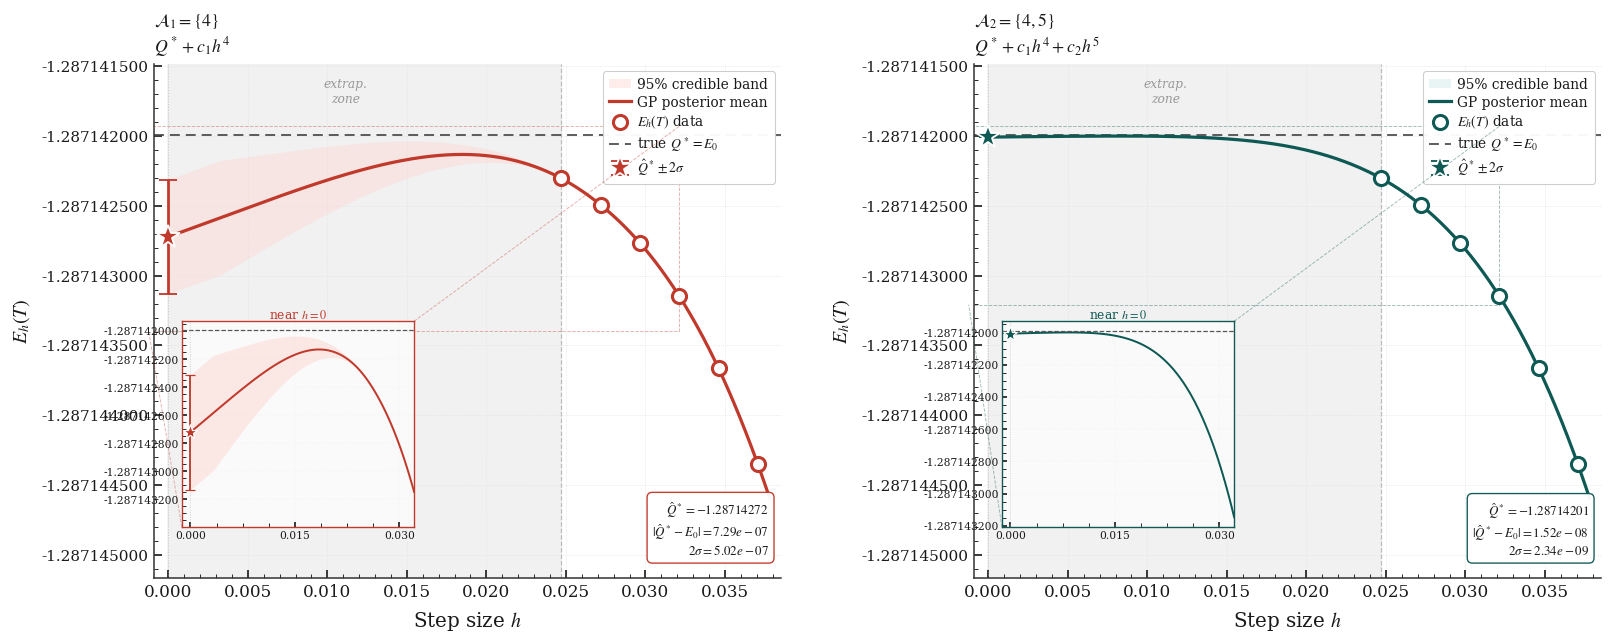

Saved → ./Three_Body_Figs/fig3_extrapolation.pdf


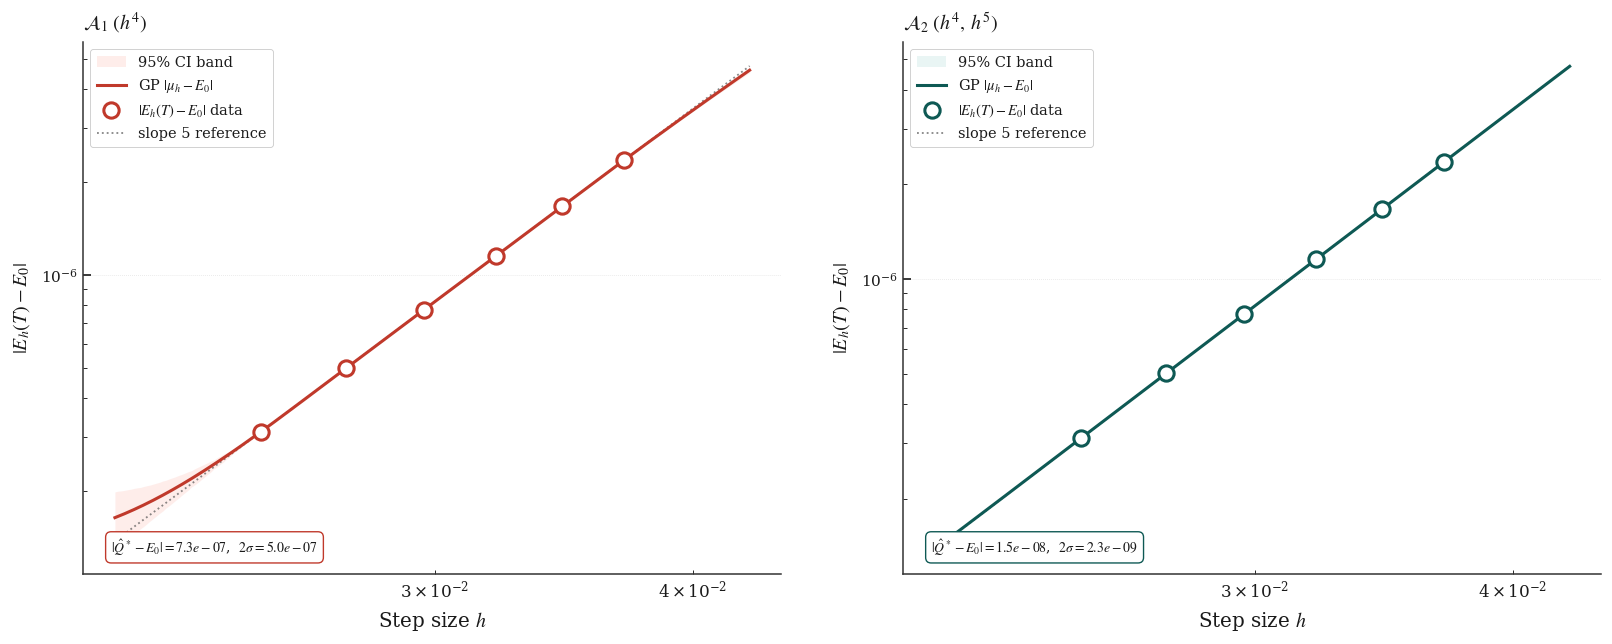

Saved → ./Three_Body_Figs/fig4_loglog.pdf

[Pareto] Timing SPRE input step sizes (RK4 only):
  h=0.02471  t=  23.27 ms  |E-E0|=3.112e-07
  h=0.02718  t=  21.22 ms  |E-E0|=5.010e-07
  h=0.02965  t=  19.55 ms  |E-E0|=7.739e-07
  h=0.03212  t=  17.85 ms  |E-E0|=1.154e-06
  h=0.03459  t=  16.64 ms  |E-E0|=1.671e-06
  h=0.03707  t=  15.56 ms  |E-E0|=2.359e-06

[Pareto] Timing extra single-h RK4 runs:
  h=0.39537  t=   1.45 ms  |E-E0|=6.692e+00
  h=0.19768  t=   2.90 ms  |E-E0|=9.662e-03
  h=0.09884  t=   5.82 ms  |E-E0|=3.128e-04
  h=0.04942  t=  11.68 ms  |E-E0|=9.921e-06
  h=0.01236  t=  46.47 ms  |E-E0|=9.736e-09
  h=0.00618  t=  93.21 ms  |E-E0|=3.043e-10
  h=0.00309  t= 185.40 ms  |E-E0|=9.505e-12

[Pareto] SPRE sweep over n  (A1={h^4}, A2={h^4,h^5}):
   n          basis        |err|       2sigma   cost(ms)
   3       A1={h^4}    1.824e-07     3.22e-07      64.04
   4       A1={h^4}    5.293e-07     3.51e-07      81.89
   4   A2={h^4,h^5}    7.960e-09     6.27e-09      81.89
   5      

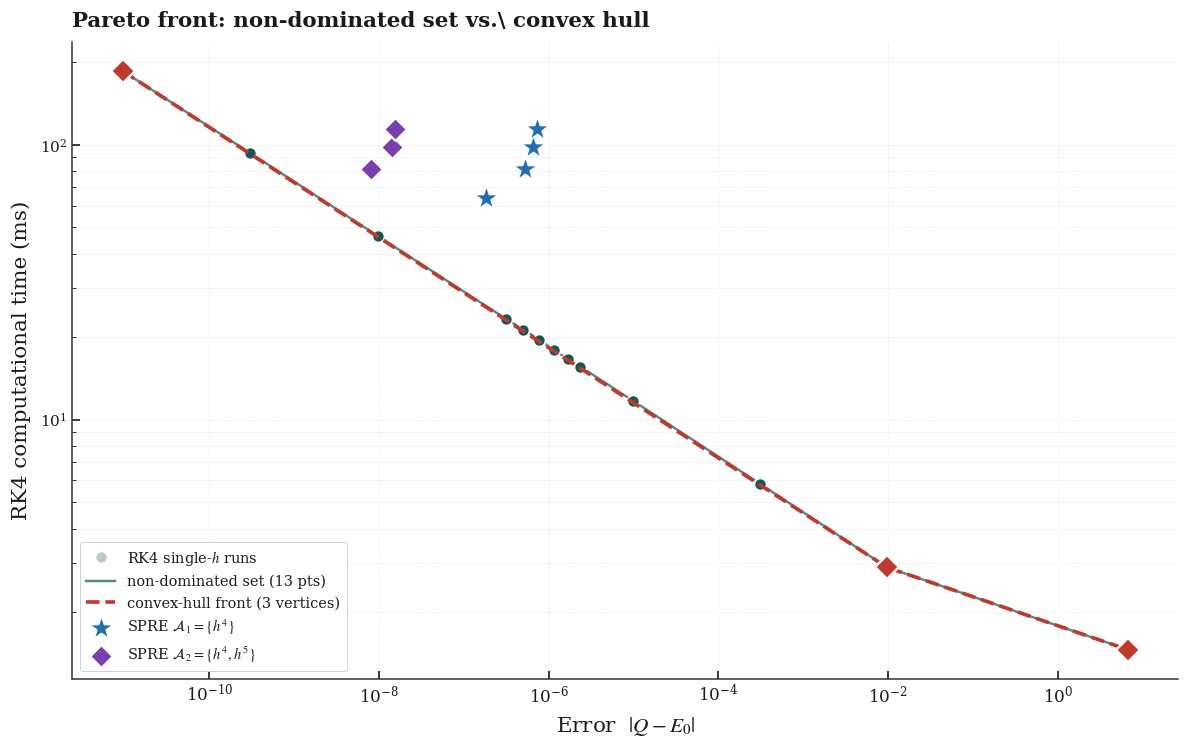


Saved → ./Three_Body_Figs/fig7_pareto_convexhull.pdf


In [ ]:
# =============================================================================
# CELL 1 — Imports & Setup
# =============================================================================
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
import warnings
warnings.filterwarnings('ignore')
import torch
from spre import SPRE, predict_normalised, x2fx

OUT_DIR = "./Three_Body_Figs"
os.makedirs(OUT_DIR, exist_ok=True)

WHITE  = '#FFFFFF'; INK = '#1A1A1A'; MUTED = '#555555'; GRID = '#E0E0E0'
C_A1_F = '#FDD8D2'; C_A1 = '#C0392B'; C_A2_F = '#CFEBE7'; C_A2 = '#0E5954'

STYLE = {
    'figure.facecolor': WHITE, 'axes.facecolor': WHITE, 'savefig.facecolor': WHITE,
    'text.color': INK, 'axes.labelcolor': INK, 'xtick.color': INK, 'ytick.color': INK,
    'axes.edgecolor': '#333333', 'legend.labelcolor': INK,
    'font.family': 'serif', 'font.serif': ['Times New Roman','Times','DejaVu Serif'],
    'mathtext.fontset': 'stix', 'font.size': 13, 'axes.linewidth': 1.1,
    'axes.labelsize': 14, 'axes.titlesize': 12, 'axes.labelpad': 6,
    'xtick.direction': 'in', 'ytick.direction': 'in',
    'xtick.major.size': 5, 'ytick.major.size': 5, 'xtick.minor.size': 2.5,
    'ytick.minor.size': 2.5, 'xtick.major.width': 1.1, 'ytick.major.width': 1.1,
    'xtick.minor.visible': True, 'ytick.minor.visible': True,
    'xtick.labelsize': 11, 'ytick.labelsize': 10, 'legend.fontsize': 9.5,
    'legend.framealpha': 0.96, 'legend.edgecolor': '#CCCCCC', 'legend.borderpad': 0.45,
    'figure.dpi': 110, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
    'pdf.fonttype': 42, 'ps.fonttype': 42,
}

def clean_ax(ax):
    ax.set_facecolor(WHITE)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    for s in ['left','bottom']:
        ax.spines[s].set_color('#333333'); ax.spines[s].set_linewidth(1.0)
    ax.grid(True, which='major', ls=':', lw=0.5, color=GRID, zorder=0)
    ax.set_axisbelow(True)
    ax.tick_params(colors=INK, which='both')
    ax.xaxis.label.set_color(INK); ax.yaxis.label.set_color(INK)
    ax.title.set_color(INK)

def auto_y_fmt(ax, ylim):
    y_range = ylim[1] - ylim[0]
    dec = max(0, -int(np.floor(np.log10(y_range))) + 1)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v:.{dec+2}f}'))


# =============================================================================
# CELL 2 — Three-body physics
# =============================================================================
G      = 1.0
masses = np.array([1.0, 1.0, 1.0])
q0 = np.array([[-0.97000436,  0.24308753],
               [ 0.97000436, -0.24308753],
               [ 0.0,         0.0       ]], dtype=np.float64)
v0 = np.array([[ 0.93240737/2,  0.86473146/2],
               [ 0.93240737/2,  0.86473146/2],
               [-0.93240737,   -0.86473146  ]], dtype=np.float64)
T_PERIOD = 6.3259
u0 = np.concatenate([q0.ravel(), v0.ravel()])

def rhs(u):
    pos, vel = u[:6].reshape(3, 2), u[6:].reshape(3, 2)
    acc = np.zeros((3, 2))
    for i in range(3):
        for j in range(3):
            if j == i: continue
            r = pos[j] - pos[i]
            acc[i] += G * masses[j] * r / np.linalg.norm(r)**3
    dudt = np.empty(12); dudt[:6] = vel.ravel(); dudt[6:] = acc.ravel()
    return dudt

def rk4_step(u, h):
    k1 = rhs(u); k2 = rhs(u + .5*h*k1)
    k3 = rhs(u + .5*h*k2); k4 = rhs(u + h*k3)
    return u + (h/6)*(k1 + 2*k2 + 2*k3 + k4)

def integrate(u0, T, h):
    u, t = u0.copy(), 0.0
    while t < T - 1e-14:
        h_eff = min(h, T - t); u = rk4_step(u, h_eff); t += h_eff
    return u

def energy(u):
    pos, vel = u[:6].reshape(3, 2), u[6:].reshape(3, 2)
    KE = 0.5 * np.sum(masses[:, None] * vel**2)
    PE = sum(-G*masses[i]*masses[j]/np.linalg.norm(pos[j]-pos[i])
             for i in range(3) for j in range(i+1, 3))
    return KE + PE

print("Reference solution ...")
h_ref = T_PERIOD / 2**17
u_ref = integrate(u0, T_PERIOD, h_ref)
print(f"  h_ref={h_ref:.2e},  energy drift={abs(energy(u_ref)-energy(u0)):.3e}")

h0    = T_PERIOD / 256
mults = np.array([1.0, 1.1, 1.2, 1.3, 1.4, 1.5])
hs    = h0 * mults
E0    = energy(u0)
print(f"\nGround truth E_0 = {E0:.10f}")

Q_energy_raw = []
print(f"\n{'h':>12}  {'E_h(T)':>16}  {'E_h(T)-E_0':>14}")
for h in hs:
    uT = integrate(u0, T_PERIOD, h)
    ET = energy(uT)
    Q_energy_raw.append(ET)
    print(f"  {h:10.6f}  {ET:16.10f}  {ET - E0:+14.4e}")
Q_energy_raw = np.array(Q_energy_raw)
Q_energy     = np.abs(Q_energy_raw - E0)


# =============================================================================
# CELL 3 — GP SPRE   (basis per Chris: A1={h^4}, A2={h^4,h^5})
# =============================================================================
# Chris's 2nd-round feedback, point 1:
#   A1 = {4}    → simplest model   Q* + c1 h^4         (min 3 data points)
#   A2 = {4,5}  → richer model     Q* + c1 h^4 + c2 h^5 (min 4 data points)
A1 = torch.tensor([[4]],       dtype=torch.int64)   # {h^4}
A2 = torch.tensor([[4], [5]],  dtype=torch.int64)   # {h^4, h^5}

def run_spre_gp(hs, Qs, A, kernel='Matern3/2', num_restarts=10):
    X  = torch.tensor(hs, dtype=torch.float64).unsqueeze(1)
    Y  = torch.tensor(Qs, dtype=torch.float64)
    At = torch.as_tensor(A, dtype=torch.int64)
    sp = SPRE(kernel_spec=kernel, dimension=1)
    sp.set_normalised_data_mad(X, Y)
    fit = sp.perform_extrapolation_optimization(At, num_restarts=num_restarts, seed=0)
    out = sp.perform_extrapolation(fit['x'], At, return_mu_and_var=True)
    return dict(mu=float(out['mu'].item()),
                std=float(max(out['var'].item(), 0.0) ** 0.5),
                sp=sp, x_raw=fit['x'])

def gp_at_h(r, h_query, A):
    x_raw = torch.as_tensor(r['x_raw'], dtype=torch.float64)
    At    = torch.as_tensor(A, dtype=torch.float64)
    sp    = r['sp']; nX = float(sp.nX.item())
    K_nn  = sp.kernel(sp.X_normalised, sp.X_normalised, x_raw)
    V_n   = x2fx(sp.X_normalised, At); Y_n = sp.Y_normalised
    mus, stds = [], []
    for h in h_query:
        xs_norm = torch.tensor([[h / nX]], dtype=torch.float64)
        k_sn = sp.kernel(xs_norm, sp.X_normalised, x_raw)
        k_ss = sp.kernel(xs_norm, xs_norm, x_raw)
        v_s  = x2fx(xs_norm, At).T
        mu_n, var_n = predict_normalised(K_nn, V_n, Y_n, k_sn, k_ss, v_s)
        mus.append(float(mu_n.item()) * sp.nY + sp.Y_mean)
        stds.append(float(max(var_n.item(), 0.0) ** 0.5) * sp.nY)
    return np.array(mus), np.array(stds)

print("\nSPRE fits (A1={h^4}, A2={h^4,h^5}):")
r1 = run_spre_gp(hs, Q_energy_raw, A1)
r2 = run_spre_gp(hs, Q_energy_raw, A2)
print(f"A1={{h^4}}     : Q*={r1['mu']:+.10f}  |Q*-E0|={abs(r1['mu']-E0):.3e}  2σ={2*r1['std']:.2e}")
print(f"A2={{h^4,h^5}} : Q*={r2['mu']:+.10f}  |Q*-E0|={abs(r2['mu']-E0):.3e}  2σ={2*r2['std']:.2e}")
print(f"E0={E0:+.10f}")


# =============================================================================
# CELL 4 — FIG 3: GP extrapolation (linear h)
# =============================================================================
with plt.rc_context(STYLE):
    fig, axes = plt.subplots(1, 2, figsize=(15, 6.2))
    fig.patch.set_facecolor(WHITE)
    configs = [
        (axes[0], r1, A1, C_A1_F, C_A1, r'$\mathcal{A}_1 = \{4\}$',
         r'$Q^* + c_1 h^4$'),
        (axes[1], r2, A2, C_A2_F, C_A2, r'$\mathcal{A}_2 = \{4,5\}$',
         r'$Q^* + c_1 h^4 + c_2 h^5$'),
    ]
    for ax, r, A, cf, cl, basis_lbl, trend_lbl in configs:
        clean_ax(ax)
        h_min, h_max = hs.min(), hs.max()
        h_dense = np.linspace(0.0, h_max * 1.02, 300)
        mu_d, s_d = gp_at_h(r, h_dense, A)
        data_spread = float(np.abs(Q_energy_raw.max() - Q_energy_raw.min()))
        s_d = np.clip(s_d, 0, 0.10 * data_spread)
        pad  = data_spread * 0.40
        ylim = (float(Q_energy_raw.min()) - pad, float(Q_energy_raw.max()) + pad)
        lo = np.clip(mu_d - 2*s_d, ylim[0]-1e-12, ylim[1]+1e-12)
        hi = np.clip(mu_d + 2*s_d, ylim[0]-1e-12, ylim[1]+1e-12)
        ax.axvspan(0, h_min, color='#F0F0F0', alpha=0.9, zorder=0)
        ax.axvline(h_min, color='#BBBBBB', lw=0.8, ls='--', zorder=1)
        ax.text(h_min*0.45, ylim[1] - pad*0.12, 'extrap.\nzone',
                fontsize=8, color='#999999', ha='center', va='top', style='italic')
        ax.fill_between(h_dense, lo, hi, color=cf, alpha=0.45, lw=0, zorder=1,
                        label='95% credible band')
        ax.plot(h_dense, mu_d, color=cl, lw=2.1, zorder=3, label='GP posterior mean')
        ax.scatter(hs, Q_energy_raw, s=85, color=WHITE, edgecolor=cl, linewidth=2.0,
                   zorder=6, label=r'$E_h(T)$ data')
        mu_0_arr, s_0_arr = gp_at_h(r, np.array([0.0]), A)
        mu_0 = float(mu_0_arr[0]); s_0 = min(float(s_0_arr[0]), 0.10 * data_spread)
        if 2*s_0 > 1e-14:
            ax.errorbar([0], [mu_0], yerr=[2*s_0], fmt='*', ms=16, color=cl,
                        mec=WHITE, mew=1.2, elinewidth=1.8, capsize=6, capthick=1.8,
                        zorder=7, label=r'$\hat{Q}^* \pm 2\sigma$')
        else:
            ax.scatter([0], [mu_0], s=250, marker='*', color=cl, edgecolor=WHITE,
                       lw=1.2, zorder=7, label=r'$\hat{Q}^*$')
        ax.axhline(E0, color='#444444', lw=1.3, ls=(0,(5,3)), alpha=0.85, zorder=2,
                   label=r'true $Q^* = E_0$')
        ax.axvline(0, color='#AAAAAA', lw=0.7, ls=':', alpha=0.5, zorder=2)
        ax.set_xlabel(r'Step size $h$', fontsize=13); ax.set_ylabel(r'$E_h(T)$', fontsize=13)
        ax.set_xlim(-h_max*0.025, h_max*1.04); ax.set_ylim(*ylim)
        auto_y_fmt(ax, ylim)
        ax.set_title(f'{basis_lbl}\n{trend_lbl}', loc='left', fontsize=11.5, pad=8,
                     fontweight='bold')
        mu_val, std_val = r['mu'], r['std']; err = abs(mu_val - E0)
        if 2*std_val < 1e-12:
            ann = (rf'$\hat{{Q}}^* = {mu_val:.8f}$'+'\n'+rf'$|\hat{{Q}}^*-E_0| = {err:.2e}$'+'\n'+r'$2\sigma \approx 0$  (collapsed)')
        else:
            ann = (rf'$\hat{{Q}}^* = {mu_val:.8f}$'+'\n'+rf'$|\hat{{Q}}^*-E_0| = {err:.2e}$'+'\n'+rf'$2\sigma = {2*std_val:.2e}$')
        ax.text(0.98, 0.04, ann, transform=ax.transAxes, fontsize=8.5, ha='right',
                va='bottom', bbox=dict(boxstyle='round,pad=0.40', facecolor=WHITE,
                          edgecolor=cl, linewidth=0.9, alpha=0.97))
        leg = ax.legend(loc='upper right', frameon=True, handlelength=1.6,
                        labelspacing=0.30, fontsize=9.0, borderpad=0.45,
                        handletextpad=0.45)
        leg.get_frame().set_facecolor(WHITE); leg.get_frame().set_linewidth(0.7)
        axin = inset_axes(ax, width='37%', height='40%', loc='lower left',
                          bbox_to_anchor=(0.045, 0.10, 1, 1),
                          bbox_transform=ax.transAxes, borderpad=0)
        axin.set_facecolor('#FAFAFA')
        for sp in axin.spines.values(): sp.set_color(cl); sp.set_linewidth(0.9)
        axin.tick_params(labelsize=7, direction='in', length=3, pad=2, colors=INK)
        axin.grid(True, ls=':', lw=0.3, color='#EEEEEE')
        h_zoom = np.linspace(0.0, h_min*1.3, 100)
        mu_z, s_z = gp_at_h(r, h_zoom, A); s_z = np.clip(s_z, 0, 0.10 * data_spread)
        q_end = float(gp_at_h(r, np.array([h_min*1.3]), A)[0][0])
        y_in_lo = min(mu_0 - 3*s_0, E0, q_end) - data_spread*0.03
        y_in_hi = max(mu_0 + 3*s_0, E0, q_end) + data_spread*0.03
        if y_in_hi - y_in_lo < 1e-12: y_in_lo, y_in_hi = E0 - 2e-8, E0 + 2e-8
        axin.fill_between(h_zoom, np.clip(mu_z-2*s_z, y_in_lo, y_in_hi),
                          np.clip(mu_z+2*s_z, y_in_lo, y_in_hi), color=cf, alpha=0.55, lw=0)
        axin.plot(h_zoom, mu_z, color=cl, lw=1.3)
        axin.axhline(E0, color='#555555', ls='--', lw=0.8)
        axin.axvline(0, color='#AAAAAA', lw=0.6, ls=':', alpha=0.5)
        if 2*s_0 > 1e-14:
            axin.errorbar([0], [mu_0], yerr=[2*s_0], fmt='*', ms=10, color=cl,
                          mec=WHITE, mew=0.8, elinewidth=1.2, capsize=3, capthick=1.2, zorder=6)
        else:
            axin.scatter([0], [mu_0], s=90, marker='*', color=cl, edgecolor=WHITE, lw=0.8, zorder=6)
        axin.set_xlim(-h_min*0.05, h_min*1.3); axin.set_ylim(y_in_lo, y_in_hi)
        auto_y_fmt(axin, (y_in_lo, y_in_hi))
        axin.xaxis.set_major_locator(mticker.MaxNLocator(3))
        axin.set_title(r'near $h=0$', fontsize=8, color=cl, pad=2)
        mark_inset(ax, axin, loc1=1, loc2=3, fc='none', ec=cl, lw=0.6, alpha=0.4, ls='--')
    plt.tight_layout(pad=1.5, w_pad=2.5)
    fig.savefig(f"{OUT_DIR}/fig3_extrapolation.pdf")
    fig.savefig(f"{OUT_DIR}/fig3_extrapolation.png", dpi=300)
    plt.show()
    print(f"Saved → {OUT_DIR}/fig3_extrapolation.pdf")


# =============================================================================
# CELL 5 — FIG 4: Log-log view
# =============================================================================
with plt.rc_context(STYLE):
    fig, axes = plt.subplots(1, 2, figsize=(15, 6.2))
    fig.patch.set_facecolor(WHITE)
    h_log = np.geomspace(hs.min()*0.85, hs.max()*1.15, 200)
    for ax, r, A, cf, cl, basis_lbl in [
        (axes[0], r1, A1, C_A1_F, C_A1, r'$\mathcal{A}_1\ (h^4)$'),
        (axes[1], r2, A2, C_A2_F, C_A2, r'$\mathcal{A}_2\ (h^4,\, h^5)$'),
    ]:
        clean_ax(ax)
        mu_log_raw, s_log = gp_at_h(r, h_log, A)
        data_spread = float(np.abs(Q_energy_raw.max() - Q_energy_raw.min()))
        s_log = np.clip(s_log, 0, 0.10 * data_spread)
        mu_log_drift = np.abs(mu_log_raw - E0)
        lo_log = np.maximum(mu_log_drift - 2*s_log, 1e-30); hi_log = mu_log_drift + 2*s_log
        ax.fill_between(h_log, lo_log, hi_log, color=cf, alpha=0.45, lw=0, zorder=1,
                        label='95% CI band')
        ax.loglog(h_log, mu_log_drift, color=cl, lw=2.0, zorder=3, label=r'GP $|\mu_h - E_0|$')
        ax.loglog(hs, Q_energy, 'o', ms=10, color=WHITE, mec=cl, mew=2.0, zorder=6,
                  label=r'$|E_h(T)-E_0|$ data')
        slope_ref = Q_energy[2] * (h_log/hs[2])**5
        ax.loglog(h_log, slope_ref, ':', color=MUTED, lw=1.2, alpha=0.7, label='slope 5 reference')
        mu_val, std_val = r['mu'], r['std']; err = abs(mu_val - E0)
        if 2*std_val < 1e-12:
            ann = rf'$|\hat{{Q}}^*-E_0|={err:.1e}$  (collapsed)'
        else:
            ann = rf'$|\hat{{Q}}^*-E_0|={err:.1e}$,  $2\sigma={2*std_val:.1e}$'
        ax.text(0.04, 0.04, ann, transform=ax.transAxes, fontsize=9,
                bbox=dict(boxstyle='round,pad=0.4', facecolor=WHITE, edgecolor=cl, linewidth=0.9))
        ax.set_xlabel(r'Step size $h$', fontsize=13)
        ax.set_ylabel(r'$|E_h(T) - E_0|$', fontsize=13)
        ax.set_title(basis_lbl, loc='left', fontweight='bold', pad=8, fontsize=13)
        leg = ax.legend(loc='upper left', handlelength=2.0, fontsize=9.5)
        leg.get_frame().set_facecolor(WHITE); leg.get_frame().set_linewidth(0.6)
    plt.tight_layout(pad=1.5, w_pad=2.5)
    fig.savefig(f"{OUT_DIR}/fig4_loglog.pdf")
    fig.savefig(f"{OUT_DIR}/fig4_loglog.png", dpi=300)
    plt.show()
    print(f"Saved → {OUT_DIR}/fig4_loglog.pdf")


import time
from scipy.spatial import ConvexHull
try:
    from paretoset import paretoset
    import pandas as pd
    HAVE_PS = True
except ImportError:
    HAVE_PS = False
    print("[warn] pip install paretoset  (falling back to manual filter)")

N_REPEAT = 3
print("\n[Pareto] Timing SPRE input step sizes (RK4 only):")
times_spre_h = np.zeros(len(hs)); err_spre_h = np.zeros(len(hs))
for i, h in enumerate(hs):
    ts = []
    for _ in range(N_REPEAT):
        t0 = time.perf_counter(); uT = integrate(u0, T_PERIOD, h); ts.append(time.perf_counter()-t0)
    times_spre_h[i] = float(np.median(ts)); err_spre_h[i] = abs(energy(uT)-E0)
    print(f"  h={h:.5f}  t={times_spre_h[i]*1000:7.2f} ms  |E-E0|={err_spre_h[i]:.3e}")

print("\n[Pareto] Timing extra single-h RK4 runs:")
h_extra = np.array([T_PERIOD/16, T_PERIOD/32, T_PERIOD/64, T_PERIOD/128,
                    T_PERIOD/512, T_PERIOD/1024, T_PERIOD/2048])
times_extra = np.zeros(len(h_extra)); err_extra = np.zeros(len(h_extra))
for i, h in enumerate(h_extra):
    ts = []
    for _ in range(N_REPEAT):
        t0 = time.perf_counter(); uT = integrate(u0, T_PERIOD, h); ts.append(time.perf_counter()-t0)
    times_extra[i] = float(np.median(ts)); err_extra[i] = abs(energy(uT)-E0)
    print(f"  h={h:.5f}  t={times_extra[i]*1000:7.2f} ms  |E-E0|={err_extra[i]:.3e}")

rk4_times = np.concatenate([times_spre_h, times_extra])
rk4_errs  = np.concatenate([err_spre_h,   err_extra])
rk4_hs    = np.concatenate([hs,           h_extra])

order = np.argsort(hs); hs_a = hs[order]; Q_a = Q_energy_raw[order]; t_a = times_spre_h[order]
print("\n[Pareto] SPRE sweep over n  (A1={h^4}, A2={h^4,h^5}):")
print(f"  {'n':>2} {'basis':>14} {'|err|':>12} {'2sigma':>12} {'cost(ms)':>10}")
spre_points = []
for n in [3,4,5,6]:
    cost = float(t_a[:n].sum())
    r = run_spre_gp(hs_a[:n], Q_a[:n], A1)
    spre_points.append(dict(n=n, basis='A1', err=abs(r['mu']-E0), time=cost, mu=r['mu'], std=r['std']))
    print(f"  {n:>2} {'A1={h^4}':>14} {abs(r['mu']-E0):>12.3e} {2*r['std']:>12.2e} {cost*1000:>10.2f}")
    if n >= 4:
        r = run_spre_gp(hs_a[:n], Q_a[:n], A2)
        spre_points.append(dict(n=n, basis='A2', err=abs(r['mu']-E0), time=cost, mu=r['mu'], std=r['std']))
        print(f"  {n:>2} {'A2={h^4,h^5}':>14} {abs(r['mu']-E0):>12.3e} {2*r['std']:>12.2e} {cost*1000:>10.2f}")

# Pareto fronts
def nondominated_mask(errs, times):
    if HAVE_PS:
        return paretoset(pd.DataFrame({'e':errs,'t':times}), sense=['min','min'])
    n=len(errs); keep=np.ones(n,bool)
    for i in range(n):
        for j in range(n):
            if i!=j and errs[j]<=errs[i] and times[j]<=times[i] and (errs[j]<errs[i] or times[j]<times[i]):
                keep[i]=False; break
    return keep

def lower_left_hull(errs, times):
    pts=np.column_stack([np.log10(errs), np.log10(times)])
    if len(pts)<3: return np.argsort(errs)
    v=ConvexHull(pts).vertices; ev,tv=errs[v],times[v]; keep=[]
    for i in range(len(v)):
        dom=any(i!=j and ev[j]<=ev[i] and tv[j]<=tv[i] and (ev[j]<ev[i] or tv[j]<tv[i]) for j in range(len(v)))
        if not dom: keep.append(v[i])
    return np.array(sorted(keep, key=lambda k: errs[k]))

nd_idx = np.where(nondominated_mask(rk4_errs, rk4_times))[0]; nd_idx = nd_idx[np.argsort(rk4_errs[nd_idx])]
ch_idx = lower_left_hull(rk4_errs, rk4_times)
print(f"\n[Pareto] non-dominated: {len(nd_idx)}/{len(rk4_errs)};  convex-hull: {len(ch_idx)} vertices")

A2_colour = '#7A3FAF'
with plt.rc_context(STYLE):
    fig, ax = plt.subplots(figsize=(11,7)); clean_ax(ax)
    ax.loglog(rk4_errs, rk4_times*1000, 'o', ms=7, color=C_A2, alpha=0.30, mec=WHITE, mew=0.8,
              zorder=3, label='RK4 single-$h$ runs')
    ax.loglog(rk4_errs[nd_idx], rk4_times[nd_idx]*1000, '-', color=C_A2, lw=1.6, alpha=0.7,
              zorder=4, label=f'non-dominated set ({len(nd_idx)} pts)')
    ax.loglog(rk4_errs[nd_idx], rk4_times[nd_idx]*1000, 'o', ms=8, color=C_A2, mec=WHITE, mew=1.2, zorder=5)
    ax.loglog(rk4_errs[ch_idx], rk4_times[ch_idx]*1000, '--', color=C_A1, lw=2.4, zorder=6,
              label=f'convex-hull front ({len(ch_idx)} vertices)')
    ax.loglog(rk4_errs[ch_idx], rk4_times[ch_idx]*1000, 'D', ms=11, color=C_A1, mec=WHITE, mew=1.6, zorder=7)
    done=set()
    for pt in spre_points:
        a1=pt['basis']=='A1'; col='#1F6FB2' if a1 else A2_colour
        lbl=(r"SPRE $\mathcal{A}_1=\{h^4\}$" if a1 else r"SPRE $\mathcal{A}_2=\{h^4,h^5\}$")
        if pt['basis'] in done: lbl=None
        else: done.add(pt['basis'])
        ax.scatter([pt['err']],[pt['time']*1000], marker='*' if a1 else 'D', s=320 if a1 else 110,
                   color=col, edgecolor=WHITE, linewidth=1.4, zorder=8, label=lbl)
    ax.set_xlabel(r'Error  $|Q - E_0|$', fontsize=14)
    ax.set_ylabel(r'RK4 computational time (ms)', fontsize=14)
    ax.set_title(r'Pareto front: non-dominated set vs.\ convex hull', loc='left',
                 fontweight='bold', pad=10, fontsize=14)
    ax.grid(True, which='both', ls=':', lw=0.5, color=GRID)
    leg=ax.legend(loc='lower left', frameon=True, fontsize=9.5, handlelength=2.0, labelspacing=0.5)
    leg.get_frame().set_facecolor(WHITE); leg.get_frame().set_linewidth(0.6)
    plt.tight_layout()
    fig.savefig(f"{OUT_DIR}/fig7_pareto_convexhull.pdf", bbox_inches='tight')
    fig.savefig(f"{OUT_DIR}/fig7_pareto_convexhull.png", dpi=300, bbox_inches='tight')
    plt.show()
    print(f"\nSaved → {OUT_DIR}/fig7_pareto_convexhull.pdf")

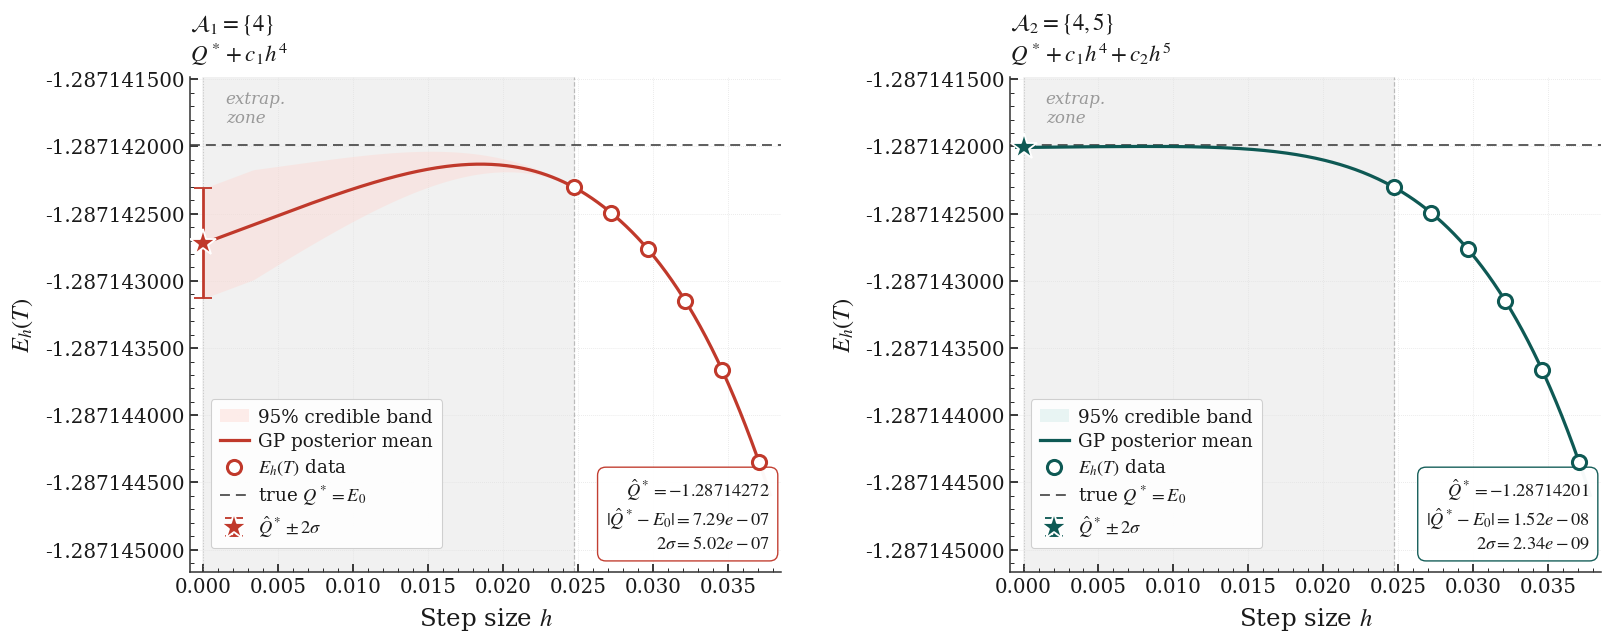

Saved → ./Three_Body_Figs/fig3_extrapolation.pdf


In [3]:
# =============================================================================
# CELL 4 — FIG 3: GP extrapolation (linear h)   [insets removed, fonts enlarged, legend relocated]
# =============================================================================
with plt.rc_context(STYLE):
    fig, axes = plt.subplots(1, 2, figsize=(15, 6.2))
    fig.patch.set_facecolor(WHITE)
    configs = [
        (axes[0], r1, A1, C_A1_F, C_A1, r'$\mathcal{A}_1 = \{4\}$',
         r'$Q^* + c_1 h^4$'),
        (axes[1], r2, A2, C_A2_F, C_A2, r'$\mathcal{A}_2 = \{4,5\}$',
         r'$Q^* + c_1 h^4 + c_2 h^5$'),
    ]
    for ax, r, A, cf, cl, basis_lbl, trend_lbl in configs:
        clean_ax(ax)
        h_min, h_max = hs.min(), hs.max()
        h_dense = np.linspace(0.0, h_max * 1.02, 300)
        mu_d, s_d = gp_at_h(r, h_dense, A)
        data_spread = float(np.abs(Q_energy_raw.max() - Q_energy_raw.min()))
        s_d = np.clip(s_d, 0, 0.10 * data_spread)
        pad  = data_spread * 0.40
        ylim = (float(Q_energy_raw.min()) - pad, float(Q_energy_raw.max()) + pad)
        lo = np.clip(mu_d - 2*s_d, ylim[0]-1e-12, ylim[1]+1e-12)
        hi = np.clip(mu_d + 2*s_d, ylim[0]-1e-12, ylim[1]+1e-12)

        ax.axvspan(0, h_min, color='#F0F0F0', alpha=0.9, zorder=0)
        ax.axvline(h_min, color='#BBBBBB', lw=0.8, ls='--', zorder=1)
        ax.text(h_min*0.06, ylim[1] - pad*0.12, 'extrap.\nzone',
                fontsize=11, color='#999999', ha='left', va='top', style='italic')

        ax.fill_between(h_dense, lo, hi, color=cf, alpha=0.45, lw=0, zorder=1,
                        label='95% credible band')
        ax.plot(h_dense, mu_d, color=cl, lw=2.1, zorder=3, label='GP posterior mean')
        ax.scatter(hs, Q_energy_raw, s=85, color=WHITE, edgecolor=cl, linewidth=2.0,
                   zorder=6, label=r'$E_h(T)$ data')

        mu_0_arr, s_0_arr = gp_at_h(r, np.array([0.0]), A)
        mu_0 = float(mu_0_arr[0]); s_0 = min(float(s_0_arr[0]), 0.10 * data_spread)
        if 2*s_0 > 1e-14:
            ax.errorbar([0], [mu_0], yerr=[2*s_0], fmt='*', ms=18, color=cl,
                        mec=WHITE, mew=1.2, elinewidth=1.8, capsize=6, capthick=1.8,
                        zorder=7, label=r'$\hat{Q}^* \pm 2\sigma$')
        else:
            ax.scatter([0], [mu_0], s=300, marker='*', color=cl, edgecolor=WHITE,
                       lw=1.2, zorder=7, label=r'$\hat{Q}^*$')

        ax.axhline(E0, color='#444444', lw=1.3, ls=(0,(5,3)), alpha=0.85, zorder=2,
                   label=r'true $Q^* = E_0$')
        ax.axvline(0, color='#AAAAAA', lw=0.7, ls=':', alpha=0.5, zorder=2)

        ax.set_xlabel(r'Step size $h$', fontsize=16)
        ax.set_ylabel(r'$E_h(T)$', fontsize=16)
        ax.set_xlim(-h_max*0.025, h_max*1.04); ax.set_ylim(*ylim)
        auto_y_fmt(ax, ylim)
        ax.tick_params(labelsize=13, which='major')
        ax.set_title(f'{basis_lbl}\n{trend_lbl}', loc='left', fontsize=15, pad=10,
                     fontweight='bold')

        mu_val, std_val = r['mu'], r['std']; err = abs(mu_val - E0)
        if 2*std_val < 1e-12:
            ann = (rf'$\hat{{Q}}^* = {mu_val:.8f}$'+'\n'+rf'$|\hat{{Q}}^*-E_0| = {err:.2e}$'+'\n'+r'$2\sigma \approx 0$  (collapsed)')
        else:
            ann = (rf'$\hat{{Q}}^* = {mu_val:.8f}$'+'\n'+rf'$|\hat{{Q}}^*-E_0| = {err:.2e}$'+'\n'+rf'$2\sigma = {2*std_val:.2e}$')
        ax.text(0.98, 0.04, ann, transform=ax.transAxes, fontsize=12, ha='right',
                va='bottom', bbox=dict(boxstyle='round,pad=0.45', facecolor=WHITE,
                          edgecolor=cl, linewidth=0.9, alpha=0.97))

        leg = ax.legend(loc='lower left', frameon=True, handlelength=1.6,
                        labelspacing=0.35, fontsize=12, borderpad=0.5,
                        handletextpad=0.5, bbox_to_anchor=(0.02, 0.03))
        leg.get_frame().set_facecolor(WHITE)
        leg.get_frame().set_linewidth(0.7)
        leg.get_frame().set_alpha(0.92)

    plt.tight_layout(pad=1.5, w_pad=2.5)
    fig.savefig(f"{OUT_DIR}/fig3_extrapolation.pdf")
    fig.savefig(f"{OUT_DIR}/fig3_extrapolation.png", dpi=300)
    plt.show()
    print(f"Saved → {OUT_DIR}/fig3_extrapolation.pdf")

[Pareto] Timing SPRE input step sizes (RK4 only):
  h=0.02471  t=  31.39 ms  |E-E0|=3.112e-07
  h=0.02718  t=  24.50 ms  |E-E0|=5.010e-07
  h=0.02965  t=  22.69 ms  |E-E0|=7.739e-07
  h=0.03212  t=  20.95 ms  |E-E0|=1.154e-06
  h=0.03459  t=  22.25 ms  |E-E0|=1.671e-06
  h=0.03707  t=  20.95 ms  |E-E0|=2.359e-06

[Pareto] Timing extra single-h RK4 runs:
  h=0.39537  t=   1.96 ms  |E-E0|=6.692e+00
  h=0.19768  t=   4.00 ms  |E-E0|=9.662e-03
  h=0.09884  t=   6.76 ms  |E-E0|=3.128e-04
  h=0.04942  t=  13.68 ms  |E-E0|=9.921e-06
  h=0.01236  t=  54.83 ms  |E-E0|=9.736e-09
  h=0.00618  t= 112.04 ms  |E-E0|=3.043e-10
  h=0.00309  t= 218.47 ms  |E-E0|=9.505e-12

[Pareto] SPRE sweep over n:
   n          basis        |err|       2sigma   cost(ms)
   3       A1={h^4}    5.236e-07     3.36e-07      78.57
   4       A1={h^4}    7.960e-09     6.27e-09      99.52
   4   A2={h^4,h^5}    6.235e-07     4.93e-07      99.52
   5       A1={h^4}    1.431e-08     0.00e+00     121.77
   5   A2={h^4,h^5}   

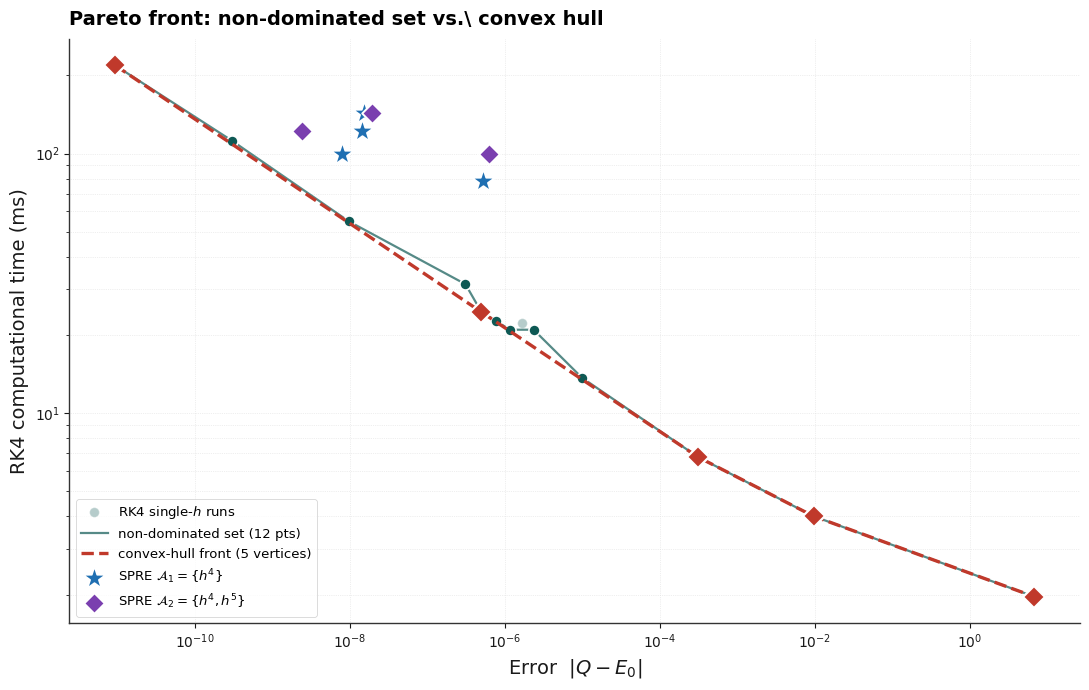


Saved → ./Three_Body_Figs/fig7_pareto_convexhull.pdf


In [4]:
# =============================================================================
# CELL 10+11 COMBINED — Pareto data collection + convex-hull front
# Self-contained: computes the Pareto data AND draws the front in one cell.
# Paste AFTER Cell 3 (needs: integrate, energy, u0, T_PERIOD, hs, E0,
#                            Q_energy_raw, run_spre_gp, A1, A2,
#                            C_A1, C_A2, INK, WHITE, GRID, clean_ax, OUT_DIR).
# Install once if needed:  pip install paretoset
# =============================================================================
import time
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import ConvexHull

# ---- dependency guard -------------------------------------------------------
for _n in ['integrate','energy','u0','T_PERIOD','hs','E0','Q_energy_raw',
           'run_spre_gp','A1','A2','clean_ax','OUT_DIR']:
    if _n not in dir():
        raise RuntimeError(f"'{_n}' missing — run Cells 1–3 first.")

# =============================================================================
# PART A — collect Pareto data (RK4-only timing, per Chris point 3)
# =============================================================================
N_REPEAT = 3

print("[Pareto] Timing SPRE input step sizes (RK4 only):")
times_spre_h = np.zeros(len(hs)); err_spre_h = np.zeros(len(hs))
for i, h in enumerate(hs):
    ts = []
    for _ in range(N_REPEAT):
        t0 = time.perf_counter(); uT = integrate(u0, T_PERIOD, h)
        ts.append(time.perf_counter()-t0)
    times_spre_h[i] = float(np.median(ts)); err_spre_h[i] = abs(energy(uT)-E0)
    print(f"  h={h:.5f}  t={times_spre_h[i]*1000:7.2f} ms  |E-E0|={err_spre_h[i]:.3e}")

print("\n[Pareto] Timing extra single-h RK4 runs:")
h_extra = np.array([T_PERIOD/16, T_PERIOD/32, T_PERIOD/64, T_PERIOD/128,
                    T_PERIOD/512, T_PERIOD/1024, T_PERIOD/2048])
times_extra = np.zeros(len(h_extra)); err_extra = np.zeros(len(h_extra))
for i, h in enumerate(h_extra):
    ts = []
    for _ in range(N_REPEAT):
        t0 = time.perf_counter(); uT = integrate(u0, T_PERIOD, h)
        ts.append(time.perf_counter()-t0)
    times_extra[i] = float(np.median(ts)); err_extra[i] = abs(energy(uT)-E0)
    print(f"  h={h:.5f}  t={times_extra[i]*1000:7.2f} ms  |E-E0|={err_extra[i]:.3e}")

rk4_times = np.concatenate([times_spre_h, times_extra])
rk4_errs  = np.concatenate([err_spre_h,   err_extra])
rk4_hs    = np.concatenate([hs,           h_extra])

# ---- SPRE sweep over n = 3,4,5,6 (RK4-only cost) ----------------------------
order = np.argsort(hs); hs_a = hs[order]; Q_a = Q_energy_raw[order]; t_a = times_spre_h[order]
print("\n[Pareto] SPRE sweep over n:")
print(f"  {'n':>2} {'basis':>14} {'|err|':>12} {'2sigma':>12} {'cost(ms)':>10}")
spre_points = []
for n in [3,4,5,6]:
    cost = float(t_a[:n].sum())
    r = run_spre_gp(hs_a[:n], Q_a[:n], A1)
    spre_points.append(dict(n=n, basis='A1', err=abs(r['mu']-E0), time=cost,
                            mu=r['mu'], std=r['std']))
    print(f"  {n:>2} {'A1={h^4}':>14} {abs(r['mu']-E0):>12.3e} {2*r['std']:>12.2e} {cost*1000:>10.2f}")
    if n >= 4:
        r = run_spre_gp(hs_a[:n], Q_a[:n], A2)
        spre_points.append(dict(n=n, basis='A2', err=abs(r['mu']-E0), time=cost,
                                mu=r['mu'], std=r['std']))
        print(f"  {n:>2} {'A2={h^4,h^5}':>14} {abs(r['mu']-E0):>12.3e} {2*r['std']:>12.2e} {cost*1000:>10.2f}")

# =============================================================================
# PART B — Pareto front: non-dominated set (paretoset) + convex hull (Chris pt 4)
# =============================================================================
try:
    from paretoset import paretoset
    import pandas as pd
    HAVE_PS = True
except ImportError:
    HAVE_PS = False
    print("\n[warn] paretoset not installed (pip install paretoset); using manual filter.")

def nondominated_mask(errs, times):
    if HAVE_PS:
        return paretoset(pd.DataFrame({'e':errs,'t':times}), sense=['min','min'])
    n=len(errs); keep=np.ones(n,bool)
    for i in range(n):
        for j in range(n):
            if i!=j and errs[j]<=errs[i] and times[j]<=times[i] and (errs[j]<errs[i] or times[j]<times[i]):
                keep[i]=False; break
    return keep

def lower_left_hull(errs, times):
    pts=np.column_stack([np.log10(errs), np.log10(times)])
    if len(pts)<3: return np.argsort(errs)
    v=ConvexHull(pts).vertices; ev,tv=errs[v],times[v]; keep=[]
    for i in range(len(v)):
        dom=any(i!=j and ev[j]<=ev[i] and tv[j]<=tv[i] and (ev[j]<ev[i] or tv[j]<tv[i]) for j in range(len(v)))
        if not dom: keep.append(v[i])
    return np.array(sorted(keep, key=lambda k: errs[k]))

nd_idx = np.where(nondominated_mask(rk4_errs, rk4_times))[0]
nd_idx = nd_idx[np.argsort(rk4_errs[nd_idx])]
ch_idx = lower_left_hull(rk4_errs, rk4_times)

print(f"\n[Pareto] non-dominated: {len(nd_idx)}/{len(rk4_errs)};  convex-hull: {len(ch_idx)} vertices")

# ---- plot -------------------------------------------------------------------
A2_colour = '#7A3FAF'
fig, ax = plt.subplots(figsize=(11,7)); clean_ax(ax)
ax.loglog(rk4_errs, rk4_times*1000, 'o', ms=7, color=C_A2, alpha=0.30,
          mec=WHITE, mew=0.8, zorder=3, label='RK4 single-$h$ runs')
ax.loglog(rk4_errs[nd_idx], rk4_times[nd_idx]*1000, '-', color=C_A2, lw=1.6,
          alpha=0.7, zorder=4, label=f'non-dominated set ({len(nd_idx)} pts)')
ax.loglog(rk4_errs[nd_idx], rk4_times[nd_idx]*1000, 'o', ms=8, color=C_A2,
          mec=WHITE, mew=1.2, zorder=5)
ax.loglog(rk4_errs[ch_idx], rk4_times[ch_idx]*1000, '--', color=C_A1, lw=2.4,
          zorder=6, label=f'convex-hull front ({len(ch_idx)} vertices)')
ax.loglog(rk4_errs[ch_idx], rk4_times[ch_idx]*1000, 'D', ms=11, color=C_A1,
          mec=WHITE, mew=1.6, zorder=7)
done=set()
for pt in spre_points:
    a1=pt['basis']=='A1'; col='#1F6FB2' if a1 else A2_colour
    lbl=(r"SPRE $\mathcal{A}_1=\{h^4\}$" if a1 else r"SPRE $\mathcal{A}_2=\{h^4,h^5\}$")
    if pt['basis'] in done: lbl=None
    else: done.add(pt['basis'])
    ax.scatter([pt['err']],[pt['time']*1000], marker='*' if a1 else 'D',
               s=320 if a1 else 110, color=col, edgecolor=WHITE, linewidth=1.4,
               zorder=8, label=lbl)
ax.set_xlabel(r'Error  $|Q - E_0|$', fontsize=14)
ax.set_ylabel(r'RK4 computational time (ms)', fontsize=14)
ax.set_title(r'Pareto front: non-dominated set vs.\ convex hull',
             loc='left', fontweight='bold', pad=10, fontsize=14)
ax.grid(True, which='both', ls=':', lw=0.5, color=GRID)
leg=ax.legend(loc='lower left', frameon=True, fontsize=9.5, handlelength=2.0,
              labelspacing=0.5); leg.get_frame().set_linewidth(0.6)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/fig7_pareto_convexhull.pdf", bbox_inches='tight')
plt.savefig(f"{OUT_DIR}/fig7_pareto_convexhull.png", dpi=300, bbox_inches='tight')
plt.show()
print(f"\nSaved → {OUT_DIR}/fig7_pareto_convexhull.pdf")

In [ ]:

# =============================================================================
# CELL 1 — Imports & Setup
# =============================================================================
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.patches import ConnectionPatch, FancyArrowPatch
import matplotlib.patches as mpatches
from matplotlib.collections import LineCollection
import warnings
warnings.filterwarnings('ignore')
import torch
from spre import SPRE, predict_normalised, x2fx

# Output folder
OUT_DIR = "./Three_Body_Figs"
os.makedirs(OUT_DIR, exist_ok=True)

# Global style ────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family':         'serif',
    'font.serif':          ['Times New Roman', 'Times', 'DejaVu Serif'],
    'mathtext.fontset':    'stix',
    'font.size':           14,
    'axes.linewidth':      1.2,
    'axes.labelsize':      16,
    'axes.titlesize':      17,
    'axes.labelpad':       8,
    'xtick.direction':     'in',
    'ytick.direction':     'in',
    'xtick.major.size':    6,
    'ytick.major.size':    6,
    'xtick.minor.size':    3,
    'ytick.minor.size':    3,
    'xtick.major.width':   1.2,
    'ytick.major.width':   1.2,
    'xtick.minor.visible': True,
    'ytick.minor.visible': True,
    'xtick.labelsize':     13,
    'ytick.labelsize':     13,
    'legend.fontsize':     12,
    'legend.framealpha':   0.95,
    'legend.edgecolor':    '#CCCCCC',
    'legend.borderpad':    0.5,
    'figure.dpi':          110,
    'savefig.dpi':         300,
    'savefig.bbox':        'tight',
    'pdf.fonttype':        42,
    'ps.fonttype':         42,
})

# Color palette ───────────────────────────────────────────────────────────────
WHITE   = '#FFFFFF'
INK     = '#1A1A2E'
MUTED   = '#6B7280'
GRID    = '#E5E7EB'
PANEL   = '#FAFAFA'

C_A1_F  = '#FDD8D2'      # A1 fill
C_A1    = '#C0392B'      # A1 line
C_A2_F  = '#CFEBE7'      # A2 fill
C_A2    = '#0E5954'      # A2 line
C_TRUTH = '#1A1A2E'

C_B1    = '#3B82F6'      # body 1 (blue)
C_B2    = '#F59E0B'      # body 2 (amber)
C_B3    = '#10B981'      # body 3 (emerald)

def clean_ax(ax):
    ax.set_facecolor(PANEL)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    for s in ['left', 'bottom']:
        ax.spines[s].set_color('#444444')
        ax.spines[s].set_linewidth(1.0)
    ax.grid(True, which='major', ls=':', lw=0.6, color=GRID, zorder=0)
    ax.grid(True, which='minor', ls=':', lw=0.3, color='#F0F0F0', zorder=0)
    ax.set_axisbelow(True)


# =============================================================================
# CELL 2 — Three-body physics: dynamics, energy, integrator
# =============================================================================
G      = 1.0
masses = np.array([1.0, 1.0, 1.0])
q0 = np.array([[-0.97000436,  0.24308753],
               [ 0.97000436, -0.24308753],
               [ 0.0,         0.0       ]], dtype=np.float64)
v0 = np.array([[ 0.93240737/2,  0.86473146/2],
               [ 0.93240737/2,  0.86473146/2],
               [-0.93240737,   -0.86473146  ]], dtype=np.float64)
T_PERIOD = 6.3259
u0 = np.concatenate([q0.ravel(), v0.ravel()])

def rhs(u):
    pos, vel = u[:6].reshape(3, 2), u[6:].reshape(3, 2)
    acc = np.zeros((3, 2))
    for i in range(3):
        for j in range(3):
            if j == i: continue
            r = pos[j] - pos[i]
            acc[i] += G * masses[j] * r / np.linalg.norm(r)**3
    dudt = np.empty(12); dudt[:6] = vel.ravel(); dudt[6:] = acc.ravel()
    return dudt

def rk4_step(u, h):
    k1 = rhs(u); k2 = rhs(u + .5*h*k1)
    k3 = rhs(u + .5*h*k2); k4 = rhs(u + h*k3)
    return u + (h/6)*(k1 + 2*k2 + 2*k3 + k4)

def integrate(u0, T, h, store_traj=False):
    u, t = u0.copy(), 0.0
    if store_traj:
        traj = [u.copy()]; ts = [t]
        while t < T - 1e-14:
            h_eff = min(h, T - t); u = rk4_step(u, h_eff); t += h_eff
            traj.append(u.copy()); ts.append(t)
        return u, np.array(traj), np.array(ts)
    while t < T - 1e-14:
        h_eff = min(h, T - t); u = rk4_step(u, h_eff); t += h_eff
    return u

def energy(u):
    pos, vel = u[:6].reshape(3, 2), u[6:].reshape(3, 2)
    KE = 0.5 * np.sum(masses[:, None] * vel**2)
    PE = sum(-G*masses[i]*masses[j]/np.linalg.norm(pos[j]-pos[i])
             for i in range(3) for j in range(i+1, 3))
    return KE + PE

# ── Reference solution ────────────────────────────────────────────────────────
print("Reference solution ...")
h_ref = T_PERIOD / 2**17
u_ref = integrate(u0, T_PERIOD, h_ref)
print(f"  h_ref = {h_ref:.2e},  reference energy drift = "
      f"{abs(energy(u_ref)-energy(u0)):.3e}")

# ── Step-size sweep (COST-SIMILAR design, per Chris) ──────────────────────────
#
#   Multipliers {1.0, 1.1, ..., 1.5} keep every run at comparable cost.
#   h0 = T/256 sits in the clean asymptotic regime so the extrapolation
#   distance to h=0 is short.
h0     = T_PERIOD / 256
mults  = np.array([1.0, 1.1, 1.2, 1.3, 1.4, 1.5])
hs     = h0 * mults

print(f"\nStep-size sweep (cost-similar, h0={h0:.4f}):")
print(f"  h values  = {hs.round(4).tolist()}")
print(f"  RK4 steps = {[int(np.ceil(T_PERIOD/h)) for h in hs]}")

Q_energy, Q_state = [], []  # legacy placeholders (overwritten below)

# ── Ground truth from conservation: E(T) = E(0) ──────────────────────────────
# Following supervisor's feedback: avoid Q* = 0 (too many bugs make code return 0).
# Use Q(h) = E_h(T) directly, with ground truth Q* = E_0 = energy(u0).
E0 = energy(u0)
print(f"\nGround truth (initial energy):  E_0 = {E0:.10f}")

Q_energy_raw = []   # Q(h) = E_h(T)         — non-zero ground truth E_0
Q_state      = []   # final-state error
print(f"\n{'h':>12}  {'E_h(T)':>16}  {'E_h(T)-E_0':>14}  {'Q_state':>14}")
for h in hs:
    uT = integrate(u0, T_PERIOD, h)
    ET = energy(uT)
    Q_energy_raw.append(ET)
    Q_state.append(np.linalg.norm(uT - u_ref))
    print(f"  {h:10.6f}  {ET:16.10f}  {ET - E0:+14.4e}  {Q_state[-1]:14.6e}")
Q_energy_raw = np.array(Q_energy_raw)
Q_state      = np.array(Q_state)

# Keep |E_h(T) - E_0| as a derived diagnostic (useful for log-log plots),
# but SPRE will now extrapolate E_h(T) itself (target = E_0, NOT zero).
Q_energy = np.abs(Q_energy_raw - E0)   # diagnostic only — for slope plots


# =============================================================================
# CELL 3 — GP SPRE  (basis = {h^4} or {h^4, h^5};  no h^4 transform)
# =============================================================================
# Per Chris's latest feedback (2nd round):
#   X = h directly (no transform)
#   A_1 = [[4]]       → trend Q* + c1*h^4              SIMPLEST model
#                        (RK4 leading-order term only)
#   A_2 = [[4],[5]]   → trend Q* + c1*h^4 + c2*h^5     richer alternative
#
# Minimum n required for each (n_params + 1 hold-out):
#   A_1: 2 params  + 1 = 3 data points minimum
#   A_2: 3 params  + 1 = 4 data points minimum
# This means SPRE may need fewer than 6 evaluations — explored in Pareto cell.
A1 = torch.tensor([[4]],       dtype=torch.int64)
A2 = torch.tensor([[4], [5]],  dtype=torch.int64)

def run_spre_gp(hs, Qs, A, kernel='Matern3/2', num_restarts=10):
    X  = torch.tensor(hs, dtype=torch.float64).unsqueeze(1)   # X = h (no transform)
    Y  = torch.tensor(Qs, dtype=torch.float64)
    At = torch.as_tensor(A, dtype=torch.int64)

    sp = SPRE(kernel_spec=kernel, dimension=1)
    sp.set_normalised_data_mad(X, Y)
    fit = sp.perform_extrapolation_optimization(At, num_restarts=num_restarts, seed=0)
    hp  = sp.extract_hyperparameters(fit['x'])
    out = sp.perform_extrapolation(fit['x'], At, return_mu_and_var=True)
    return dict(
        mu=float(out['mu'].item()),
        std=float(max(out['var'].item(), 0.0) ** 0.5),
        amplitude=float(hp['amplitude']),
        lengthscale=float(hp['lengthscale']),
        cv=float(fit['cv'].item()),
        sp=sp, x_raw=fit['x'],
    )

def gp_at_h(r, h_query, A):
    """GP posterior (mean, std) at arbitrary h values (original Q scale)."""
    x_raw = torch.as_tensor(r['x_raw'], dtype=torch.float64)
    At    = torch.as_tensor(A, dtype=torch.float64)
    sp    = r['sp']
    nX    = float(sp.nX.item())
    K_nn  = sp.kernel(sp.X_normalised, sp.X_normalised, x_raw)
    V_n   = x2fx(sp.X_normalised, At)
    Y_n   = sp.Y_normalised
    mus, stds = [], []
    for h in h_query:
        xs_norm = torch.tensor([[h / nX]], dtype=torch.float64)
        k_sn = sp.kernel(xs_norm, sp.X_normalised, x_raw)
        k_ss = sp.kernel(xs_norm, xs_norm, x_raw)
        v_s  = x2fx(xs_norm, At).T
        mu_n, var_n = predict_normalised(K_nn, V_n, Y_n, k_sn, k_ss, v_s)
        mus.append(float(mu_n.item()) * sp.nY + sp.Y_mean)
        stds.append(float(max(var_n.item(), 0.0) ** 0.5) * sp.nY)
    return np.array(mus), np.array(stds)

print("\nSPRE fits on Q(h) = E_h(T)  (ground truth = E_0):")
r1 = run_spre_gp(hs, Q_energy_raw, A1)
r2 = run_spre_gp(hs, Q_energy_raw, A2)
print(f"A1 (h^4):        Q* = {r1['mu']:+.10f}   "
      f"|Q* - E_0| = {abs(r1['mu']-E0):.3e}   2σ = {2*r1['std']:.2e}")
print(f"A2 (h^4, h^5):   Q* = {r2['mu']:+.10f}   "
      f"|Q* - E_0| = {abs(r2['mu']-E0):.3e}   2σ = {2*r2['std']:.2e}")
print(f"True E_0        = {E0:+.10f}")


# =============================================================================
# CELL 4 — FIG 1: Figure-eight orbit
# =============================================================================
_, traj_viz, t_viz = integrate(u0, T_PERIOD, T_PERIOD/2000, store_traj=True)
pos_viz = traj_viz[:, :6].reshape(-1, 3, 2)

fig, ax = plt.subplots(figsize=(9, 6))
clean_ax(ax)

for i, (c, lb) in enumerate(zip([C_B1, C_B2, C_B3], ['Body 1','Body 2','Body 3'])):
    pts = pos_viz[:, i, :]
    segs = np.array([pts[:-1], pts[1:]]).transpose(1, 0, 2)
    alphas = np.linspace(0.3, 1.0, len(segs))
    lc = LineCollection(segs,
                        colors=[(*plt.matplotlib.colors.to_rgb(c), a) for a in alphas],
                        linewidths=2.0, zorder=2)
    ax.add_collection(lc)
    ax.scatter(pts[0, 0], pts[0, 1], s=120, color=c, edgecolor=WHITE, lw=2,
               zorder=5, label=lb)
    ax.scatter(pts[-1, 0], pts[-1, 1], s=70, color=c, marker='X',
               edgecolor=WHITE, lw=1.5, zorder=5)

ax.scatter(0, 0, s=40, marker='+', color=MUTED, lw=2, zorder=3)
ax.text(0.02, -0.08, 'COM', fontsize=11, color=MUTED, style='italic')

ax.set_xlabel(r'$x$'); ax.set_ylabel(r'$y$')
ax.set_aspect('equal')
ax.set_title(f'Figure-Eight Three-Body Orbit  ·  $T \\approx {T_PERIOD:.4f}$', pad=12)

leg = ax.legend(loc='upper left', frameon=True, ncol=3,
                handletextpad=0.5, columnspacing=1.0)
leg.get_frame().set_linewidth(0.6)
ax.text(0.98, 0.04,
        r'$m_1=m_2=m_3=1,\ G=1$' + '\n' + r'one full period shown',
        transform=ax.transAxes, fontsize=11, color=MUTED,
        ha='right', va='bottom', style='italic',
        bbox=dict(boxstyle='round,pad=0.4', facecolor=WHITE,
                  edgecolor=GRID, linewidth=0.6))
plt.savefig(f"{OUT_DIR}/fig1_orbit.pdf")
plt.savefig(f"{OUT_DIR}/fig1_orbit.png", dpi=300)
plt.show()
print(f"Saved → {OUT_DIR}/fig1_orbit.pdf")


# =============================================================================
# CELL 5 — FIG 2: Step-size convergence (log-log) — both observables
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(15, 6.2))
h_ref_line = np.geomspace(hs.min()*0.6, hs.max()*1.4, 100)

# Panel (a) — Energy drift
ax = axes[0]; clean_ax(ax)
slope4_e = Q_energy[2] * (h_ref_line/hs[2])**4
slope5_e = Q_energy[2] * (h_ref_line/hs[2])**5
ax.loglog(h_ref_line, slope4_e, '--', color=MUTED, lw=1.0, alpha=0.6, label='slope 4 ref')
ax.loglog(h_ref_line, slope5_e, ':',  color=MUTED, lw=1.0, alpha=0.8, label='slope 5 ref')
ax.loglog(hs, Q_energy, 'o', ms=10, color=C_A1, mec=WHITE, mew=1.5,
          zorder=5, label=r'$Q(h)$ measured')
p_e = np.polyfit(np.log(hs), np.log(Q_energy), 1)[0]
ax.text(0.04, 0.96, f'fitted slope = {p_e:.3f}',
        transform=ax.transAxes, fontsize=13, va='top',
        bbox=dict(boxstyle='round,pad=0.4', facecolor=WHITE,
                  edgecolor=C_A1, linewidth=0.8))
ax.set_xlabel(r'Step size $h$')
ax.set_ylabel(r'Energy drift  $|E_h(T) - E_h(0)|$')
ax.set_title('(a)  Energy drift', loc='left', fontweight='bold', pad=10)
ax.legend(loc='lower right', handlelength=2.4)

# Panel (b) — Final-state error
ax = axes[1]; clean_ax(ax)
slope4_s = Q_state[2] * (h_ref_line/hs[2])**4
slope5_s = Q_state[2] * (h_ref_line/hs[2])**5
ax.loglog(h_ref_line, slope4_s, '--', color=MUTED, lw=1.0, alpha=0.6, label='slope 4 ref')
ax.loglog(h_ref_line, slope5_s, ':',  color=MUTED, lw=1.0, alpha=0.8, label='slope 5 ref')
ax.loglog(hs, Q_state, 's', ms=10, color=C_A2, mec=WHITE, mew=1.5,
          zorder=5, label=r'$Q(h)$ measured')
p_s = np.polyfit(np.log(hs), np.log(Q_state), 1)[0]
ax.text(0.04, 0.96, f'fitted slope = {p_s:.3f}',
        transform=ax.transAxes, fontsize=13, va='top',
        bbox=dict(boxstyle='round,pad=0.4', facecolor=WHITE,
                  edgecolor=C_A2, linewidth=0.8))
ax.set_xlabel(r'Step size $h$')
ax.set_ylabel(r'Final-state error  $\|y_h(T) - y_{\rm ref}(T)\|$')
ax.set_title('(b)  Final-state error', loc='left', fontweight='bold', pad=10)
ax.legend(loc='lower right', handlelength=2.4)

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/fig2_convergence.pdf")
plt.savefig(f"{OUT_DIR}/fig2_convergence.png", dpi=300)
plt.show()
print(f"Saved → {OUT_DIR}/fig2_convergence.pdf")


# =============================================================================
# CELL 6 — FIG 3: Extrapolation in linear h space (revised — no h^4 transform)
# =============================================================================
# Main plot: GP posterior in linear h, with the Q* extrapolation at h=0.
# An inset zooms in near h=0 so the small Q* and its 2σ are visible.
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

h_dense = np.linspace(0.0, hs.max()*1.05, 300)
mu1_d, s1_d = gp_at_h(r1, h_dense, A1)
mu2_d, s2_d = gp_at_h(r2, h_dense, A2)
mu1_0, s1_0 = gp_at_h(r1, np.array([0.0]), A1)
mu2_0, s2_0 = gp_at_h(r2, np.array([0.0]), A2)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, r, mu_d, s_d, mu_0, s_0, color_f, color_l, basis_lbl, qstar_lbl in [
    (axes[0], r1, mu1_d, s1_d, mu1_0, s1_0, C_A1_F, C_A1,
     r'$\mathcal{A}_1 = \{4, 5\}$', r'$Q^* + c_1 h^4 + c_2 h^5$'),
    (axes[1], r2, mu2_d, s2_d, mu2_0, s2_0, C_A2_F, C_A2,
     r'$\mathcal{A}_2 = \{4, 5, 6\}$', r'$Q^* + c_1 h^4 + c_2 h^5 + c_3 h^6$'),
]:
    clean_ax(ax)
    lo, hi = mu_d - 2*s_d, mu_d + 2*s_d
    ax.fill_between(h_dense, lo, hi, color=color_f, alpha=0.55, lw=0, zorder=1,
                    label='95% credible band')
    ax.plot(h_dense, mu_d, color=color_l, lw=2.2, zorder=3, label='GP posterior mean')
    ax.scatter(hs, Q_energy_raw, s=110, color=WHITE, edgecolor=color_l,
               linewidth=2.0, zorder=6, label=r'Data $E_h(T)$')

    # Q* anchor at h=0
    if 2*float(s_0) > 1e-14:
        ax.errorbar([0], [float(mu_0)], yerr=[2*float(s_0)],
                    fmt='*', ms=24, color=color_l, mec=WHITE, mew=1.5,
                    elinewidth=2.0, capsize=8, capthick=2.0,
                    zorder=7, label=rf'$\hat Q^* \pm 2\sigma$')
    else:
        ax.scatter([0], [float(mu_0)], s=400, marker='*',
                   color=color_l, edgecolor=WHITE, linewidth=1.5,
                   zorder=7, label=rf'$\hat Q^*$ (collapsed)')

    # Ground truth reference line: E_0 (not zero!)
    ax.axhline(E0, color=MUTED, lw=1.2, ls='--', alpha=0.9, zorder=2,
               label=rf'true $Q^* = E_0$')
    ax.axvline(0, color=MUTED, lw=0.8, ls=':', alpha=0.5, zorder=2)
    ax.set_xlabel(r'Step size $h$', fontsize=15)
    ax.set_ylabel(r'$E_h(T)$', fontsize=15)
    ax.set_title(f'{basis_lbl}    trend: {qstar_lbl}',
                 loc='left', fontweight='bold', pad=10, fontsize=13)

    # Annotation box — now reports distance to E_0, not to 0
    mu_val, std_val = r['mu'], r['std']
    err_to_truth = abs(mu_val - E0)
    if 2*std_val < 1e-12:
        ann = (rf'$\hat Q^* = {mu_val:+.6f}$' + '\n'
               + rf'$|\hat Q^* - E_0| = {err_to_truth:.2e}$' + '\n'
               + r'$2\sigma \approx 0$ (collapsed)' + '\n'
               + rf'true $E_0 = {E0:+.6f}$')
    else:
        ann = (rf'$\hat Q^* = {mu_val:+.6f}$' + '\n'
               + rf'$|\hat Q^* - E_0| = {err_to_truth:.2e}$' + '\n'
               + rf'$2\sigma = {2*std_val:.2e}$' + '\n'
               + rf'true $E_0 = {E0:+.6f}$')
    ax.text(0.97, 0.04, ann, transform=ax.transAxes, fontsize=10,
            ha='right', va='bottom',
            bbox=dict(boxstyle='round,pad=0.45', facecolor=WHITE,
                      edgecolor=color_l, linewidth=1.0))

    leg = ax.legend(loc='upper left', frameon=True, handlelength=2.0,
                    labelspacing=0.4, fontsize=11)
    leg.get_frame().set_linewidth(0.6)
    ax.set_xlim(-hs.max()*0.04, hs.max()*1.05)

    # Inset: zoom near h = 0 to see Q* converge to E_0
    axin = inset_axes(ax, width="40%", height="40%", loc='center right',
                      borderpad=1.5)
    axin.set_facecolor(WHITE)
    for sp in axin.spines.values():
        sp.set_color(color_l); sp.set_linewidth(1.2)
    axin.tick_params(labelsize=8.5, direction='in')
    axin.grid(True, ls=':', lw=0.4, color=GRID)

    h_zoom = np.linspace(0.0, hs.min()*1.05, 120)
    mu_z, s_z = gp_at_h(r, h_zoom, A1 if r is r1 else A2)
    axin.fill_between(h_zoom, mu_z - 2*s_z, mu_z + 2*s_z,
                      color=color_f, alpha=0.6, lw=0)
    axin.plot(h_zoom, mu_z, color=color_l, lw=1.6)
    axin.errorbar([0], [float(mu_0)], yerr=[2*float(s_0)],
                  fmt='*', ms=14, color=color_l, mec=WHITE, mew=1.0,
                  elinewidth=1.6, capsize=4, capthick=1.6, zorder=6)
    axin.axhline(E0, color=MUTED, ls='--', lw=1.0)
    axin.set_xlim(-hs.min()*0.07, hs.min()*1.05)
    axin.set_xlabel('$h$', fontsize=9, labelpad=1)
    axin.set_title(r'zoom near $h=0$', fontsize=9, color=color_l, pad=3)

fig.suptitle(
    r'GP Richardson Extrapolation:  $\hat Q^*=\lim_{h\to 0} E_h(T)$  '
    r'(true value $E_0$, not zero)',
    fontsize=16, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/fig3_extrapolation.pdf")
plt.savefig(f"{OUT_DIR}/fig3_extrapolation.png", dpi=300)
plt.show()
print(f"Saved → {OUT_DIR}/fig3_extrapolation.pdf")


# =============================================================================
# CELL 7 — FIG 4: Log-log view with GP posterior
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
h_log = np.geomspace(hs.min()*0.85, hs.max()*1.15, 200)

for ax, r, A, color_f, color_l, basis_lbl in [
    (axes[0], r1, A1, C_A1_F, C_A1, r'$\mathcal{A}_1$  $(h^4,\, h^5)$'),
    (axes[1], r2, A2, C_A2_F, C_A2, r'$\mathcal{A}_2$  $(h^4,\, h^5,\, h^6)$'),
]:
    clean_ax(ax)
    # GP fits E_h(T); convert to |E_h(T) - E_0| to match the log-log diagnostic axis
    mu_log_raw, s_log = gp_at_h(r, h_log, A)
    mu_log_drift = np.abs(mu_log_raw - E0)   # |GP mean - E_0|, comparable to Q_energy
    # Note: 2σ band in drift space is the same (E_0 is a constant shift)
    lo_log = np.maximum(mu_log_drift - 2*s_log, 1e-30)
    hi_log = mu_log_drift + 2*s_log
    ax.fill_between(h_log, lo_log, hi_log,
                    color=color_f, alpha=0.55, lw=0, zorder=1,
                    label='95% CI band')
    ax.loglog(h_log, mu_log_drift, color=color_l, lw=2.0,
              zorder=3, label=r'GP $|E_h(T)\!-\!E_0|$')
    ax.loglog(hs, Q_energy, 'o', ms=11, color=WHITE,
              mec=color_l, mew=2.0, zorder=6, label='Data points')
    slope_ref = Q_energy[2] * (h_log/hs[2])**5
    ax.loglog(h_log, slope_ref, ':', color=MUTED, lw=1.0, alpha=0.7,
              label='slope 5 reference')

    mu_val, std_val = r['mu'], r['std']
    err_to_E0 = abs(mu_val - E0)
    if 2*std_val < 1e-12:
        ann = rf'$|\hat Q^* - E_0|={err_to_E0:.1e}$  (collapsed)'
    else:
        ann = rf'$|\hat Q^* - E_0|={err_to_E0:.1e}$, $2\sigma={2*std_val:.1e}$'
    ax.text(0.04, 0.04, ann,
            transform=ax.transAxes, fontsize=10,
            bbox=dict(boxstyle='round,pad=0.4', facecolor=WHITE,
                      edgecolor=color_l, linewidth=0.9))
    ax.set_xlabel(r'Step size $h$')
    ax.set_ylabel(r'$|E_h(T) - E_0|$  (diagnostic)')
    ax.set_title(basis_lbl, loc='left', fontweight='bold', pad=10, fontsize=14)
    leg = ax.legend(loc='upper left', handlelength=2.4, fontsize=10)
    leg.get_frame().set_linewidth(0.6)

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/fig4_loglog.pdf")
plt.savefig(f"{OUT_DIR}/fig4_loglog.png", dpi=300)
plt.show()
print(f"Saved → {OUT_DIR}/fig4_loglog.pdf")


# =============================================================================
# CELL 8 — FIG 5: Sequential Q* convergence (A1 vs A2)
# =============================================================================
Qs_seq1, Qs_lo1, Qs_hi1 = [], [], []
Qs_seq2, Qs_lo2, Qs_hi2 = [], [], []

for n in range(3, len(hs)+1):
    r = run_spre_gp(hs[:n], Q_energy_raw[:n], A1)
    Qs_seq1.append(r['mu'])
    Qs_lo1.append(r['mu'] - 2*r['std'])
    Qs_hi1.append(r['mu'] + 2*r['std'])

for n in range(4, len(hs)+1):  # A2 needs ≥4 points
    try:
        r = run_spre_gp(hs[:n], Q_energy_raw[:n], A2)
        Qs_seq2.append(r['mu'])
        Qs_lo2.append(r['mu'] - 2*r['std'])
        Qs_hi2.append(r['mu'] + 2*r['std'])
    except Exception:
        Qs_seq2.append(np.nan); Qs_lo2.append(np.nan); Qs_hi2.append(np.nan)

ns1 = np.arange(3, len(hs)+1)
ns2 = np.arange(4, len(hs)+1)
Qs_seq1 = np.array(Qs_seq1); Qs_lo1 = np.array(Qs_lo1); Qs_hi1 = np.array(Qs_hi1)
Qs_seq2 = np.array(Qs_seq2); Qs_lo2 = np.array(Qs_lo2); Qs_hi2 = np.array(Qs_hi2)

fig, ax = plt.subplots(figsize=(11, 6.5))
clean_ax(ax)
ax.fill_between(ns1, Qs_lo1, Qs_hi1, color=C_A1_F, alpha=0.5, lw=0, zorder=1,
                label=r'$\mathcal{A}_1$ 95% CI')
ax.plot(ns1, Qs_seq1, 'o-', color=C_A1, lw=2.0, ms=10, mec=WHITE, mew=1.5,
        zorder=4, label=r'$\hat Q^*_{\mathcal{A}_1}\ (h^4,h^5)$')
mask2 = ~np.isnan(Qs_seq2)
if mask2.any():
    ax.fill_between(ns2[mask2], Qs_lo2[mask2], Qs_hi2[mask2],
                    color=C_A2_F, alpha=0.5, lw=0, zorder=1,
                    label=r'$\mathcal{A}_2$ 95% CI')
    ax.plot(ns2[mask2], Qs_seq2[mask2], 's-', color=C_A2, lw=2.0, ms=10,
            mec=WHITE, mew=1.5, zorder=4,
            label=r'$\hat Q^*_{\mathcal{A}_2}\ (h^4,h^5,h^6)$')
ax.axhline(E0, color=INK, ls='--', lw=1.5, alpha=0.7, zorder=2,
           label=rf'true $Q^* = E_0$')
ax.set_xlabel(r'Number of step sizes $h$ used')
ax.set_ylabel(r'$\hat Q^*$  (extrapolated $E_h(T)$)')
ax.set_title('Sequential convergence of the SPRE estimate',
             loc='left', fontweight='bold', pad=10)
ax.set_xticks(np.arange(3, len(hs)+1))
leg = ax.legend(loc='upper right', frameon=True, handlelength=2.0,
                labelspacing=0.4, ncol=2)
leg.get_frame().set_linewidth(0.6)
ax.annotate(r'$\mathcal{A}_2$ requires $n \geq 4$',
            xy=(4, Qs_seq2[0] if mask2.any() and not np.isnan(Qs_seq2[0]) else 0),
            xytext=(0.55, 0.15), textcoords='axes fraction',
            fontsize=11, color=C_A2, style='italic',
            arrowprops=dict(arrowstyle='->', color=C_A2, lw=1.0, alpha=0.7))
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/fig5_sequential.pdf")
plt.savefig(f"{OUT_DIR}/fig5_sequential.png", dpi=300)
plt.show()
print(f"Saved → {OUT_DIR}/fig5_sequential.pdf")


# =============================================================================
# CELL 9 — FIG 6: Local convergence order p_eff
# =============================================================================
p_eff_e = np.log(Q_energy[1:]/Q_energy[:-1]) / np.log(hs[1:]/hs[:-1])
p_eff_s = np.log(Q_state[1:]/Q_state[:-1])   / np.log(hs[1:]/hs[:-1])
h_mid   = np.sqrt(hs[1:]*hs[:-1])

fig, ax = plt.subplots(figsize=(10, 6))
clean_ax(ax)
ax.axhspan(3.5, 5.5, color=GRID, alpha=0.3, zorder=0)
ax.axhline(4, color=MUTED, ls='--', lw=1.5, alpha=0.8, label=r'RK4 theory: $p=4$')
ax.axhline(5, color=MUTED, ls=':',  lw=1.2, alpha=0.6, label=r'next order: $p=5$')
ax.semilogx(h_mid, p_eff_e, 'o-', color=C_A1, lw=2.0, ms=12, mec=WHITE, mew=1.5,
            label='energy drift', zorder=4)
ax.semilogx(h_mid, p_eff_s, 's-', color=C_A2, lw=2.0, ms=12, mec=WHITE, mew=1.5,
            label='final-state error', zorder=4)
ax.set_xlabel(r'Geometric midpoint $\sqrt{h_i h_{i+1}}$')
ax.set_ylabel(r'Local effective order  $p_{\rm eff}$')
ax.set_title('Local convergence order — measured between adjacent $h$ values',
             loc='left', fontweight='bold', pad=10)
ax.set_ylim(3.5, 5.7)
leg = ax.legend(loc='lower right', frameon=True, handlelength=2.4)
leg.get_frame().set_linewidth(0.6)
ax.text(0.03, 0.95,
        'figure-eight symmetry suppresses\nleading $h^4$ term — observed\norder is closer to 5',
        transform=ax.transAxes, fontsize=10, va='top', style='italic', color=INK,
        bbox=dict(boxstyle='round,pad=0.4', facecolor=WHITE,
                  edgecolor=GRID, linewidth=0.6))
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/fig6_local_order.pdf")
plt.savefig(f"{OUT_DIR}/fig6_local_order.png", dpi=300)
plt.show()
print(f"Saved → {OUT_DIR}/fig6_local_order.pdf")

print("\n" + "="*60)
print("All figures saved to:", OUT_DIR)
print("="*60)



import time


N_REPEAT = 3   # repeat each h; take median to denoise

print("\n[Pareto] Timing the SPRE input step sizes (RK4 only):")
times_spre_h = np.zeros(len(hs))   # pure RK4 time per h
err_spre_h   = np.zeros(len(hs))   # |E_h(T) - E_0|
for i, h in enumerate(hs):
    ts = []
    for _ in range(N_REPEAT):
        t0 = time.perf_counter()
        uT = integrate(u0, T_PERIOD, h)
        ts.append(time.perf_counter() - t0)
    times_spre_h[i] = float(np.median(ts))
    err_spre_h[i]   = abs(energy(uT) - E0)
    print(f"  h={h:.5f}   RK4 time={times_spre_h[i]*1000:7.2f} ms   "
          f"|E_h(T)-E_0|={err_spre_h[i]:.3e}")

# ── 2. Broader range of single-h RK4 runs — to map the full Pareto front ────
print("\n[Pareto] Timing extra single-h RK4 runs to map the front:")
h_extra = np.array([
    T_PERIOD / 16,    # very coarse
    T_PERIOD / 32,
    T_PERIOD / 64,
    T_PERIOD / 128,
    T_PERIOD / 512,
    T_PERIOD / 1024,  # very fine
    T_PERIOD / 2048,
])
times_extra = np.zeros(len(h_extra))
err_extra   = np.zeros(len(h_extra))
for i, h in enumerate(h_extra):
    ts = []
    for _ in range(N_REPEAT):
        t0 = time.perf_counter()
        uT = integrate(u0, T_PERIOD, h)
        ts.append(time.perf_counter() - t0)
    times_extra[i] = float(np.median(ts))
    err_extra[i]   = abs(energy(uT) - E0)
    print(f"  h={h:.5f}   RK4 time={times_extra[i]*1000:7.2f} ms   "
          f"|E_h(T)-E_0|={err_extra[i]:.3e}")

# All single-h RK4 points (these define the achievable RK4 Pareto front)
rk4_times = np.concatenate([times_spre_h, times_extra])   # seconds
rk4_errs  = np.concatenate([err_spre_h,   err_extra])
rk4_hs    = np.concatenate([hs,           h_extra])


# Sort by ascending h (already sorted, but be explicit)
order_asc      = np.argsort(hs)
hs_asc         = hs[order_asc]
Q_raw_asc      = Q_energy_raw[order_asc]
times_spre_asc = times_spre_h[order_asc]

print("\n[Pareto] SPRE sweep over n (data-set size), RK4-only cost:")
print(f"  {'n':>2} {'basis':>14} {'Q*':>16} {'|err|':>12} {'2sigma':>12} {'cost(ms)':>10}")
spre_points = []   # list of dicts: n, basis, err, time
for n in [3, 4, 5, 6]:
    h_sub      = hs_asc[:n]
    Q_sub      = Q_raw_asc[:n]
    cost_n     = float(times_spre_asc[:n].sum())   # RK4 cost only

    # A_1 needs n >= 3
    if n >= 3:
        r_n = run_spre_gp(h_sub, Q_sub, A1)
        err_n = abs(r_n['mu'] - E0)
        spre_points.append(dict(n=n, basis='A1', err=err_n, time=cost_n,
                                mu=r_n['mu'], std=r_n['std']))
        print(f"  {n:>2} {'A1={h^4}':>14} {r_n['mu']:>+16.10f} "
              f"{err_n:>12.3e} {2*r_n['std']:>12.2e} {cost_n*1000:>10.2f}")

    # A_2 needs n >= 4
    if n >= 4:
        r_n = run_spre_gp(h_sub, Q_sub, A2)
        err_n = abs(r_n['mu'] - E0)
        spre_points.append(dict(n=n, basis='A2', err=err_n, time=cost_n,
                                mu=r_n['mu'], std=r_n['std']))
        print(f"  {n:>2} {'A2={h^4,h^5}':>14} {r_n['mu']:>+16.10f} "
              f"{err_n:>12.3e} {2*r_n['std']:>12.2e} {cost_n*1000:>10.2f}")

print(f"\n[Pareto] {len(spre_points)} SPRE points collected (varying n and basis).")


from scipy.spatial import ConvexHull

def pareto_front(errs, times):
    """
    Return indices of points that lie on the Pareto front
    (no other point dominates them on BOTH error and time).
    """
    n = len(errs)
    is_pareto = np.ones(n, dtype=bool)
    for i in range(n):
        for j in range(n):
            if i == j: continue
            # j dominates i if j is <= on both axes AND < on at least one
            if (errs[j] <= errs[i]) and (times[j] <= times[i]) \
               and ((errs[j] < errs[i]) or (times[j] < times[i])):
                is_pareto[i] = False
                break
    return np.where(is_pareto)[0]

# Pareto-optimal subset of RK4 single-h runs
pareto_idx = pareto_front(rk4_errs, rk4_times)
pareto_idx = pareto_idx[np.argsort(rk4_errs[pareto_idx])]   # sort by error
pareto_errs  = rk4_errs[pareto_idx]
pareto_times = rk4_times[pareto_idx]
pareto_hs    = rk4_hs[pareto_idx]

print(f"\n[Pareto] Pareto-optimal RK4 runs: {len(pareto_idx)} / {len(rk4_errs)}")
for h, e, t in zip(pareto_hs, pareto_errs, pareto_times):
    print(f"  h={h:.5f}   err={e:.3e}   time={t*1000:.2f} ms")

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 7))
clean_ax(ax)

# All RK4 single-h runs as light dots
ax.loglog(rk4_errs, rk4_times*1000, 'o', ms=7, color=C_A2,
          alpha=0.35, mec=WHITE, mew=0.8, zorder=3,
          label='RK4 single-$h$ runs (all)')

# Pareto-optimal RK4 front (solid line)
ax.loglog(pareto_errs, pareto_times*1000, '-', color=C_A2, lw=2.2,
          zorder=4, label='RK4 Pareto front (lower envelope)')
ax.loglog(pareto_errs, pareto_times*1000, 'o', ms=10, color=C_A2,
          mec=WHITE, mew=1.6, zorder=5)

# Annotate Pareto-optimal h's
for h, e, t in zip(pareto_hs, pareto_errs, pareto_times):
    ax.annotate(f'  $h$={h:.3g}', xy=(e, t*1000), xytext=(6, 0),
                textcoords='offset points', fontsize=8.5, color=INK,
                va='center', ha='left')

# SPRE points — different markers per basis, label by n
A1_colour = C_A1
A2_colour = '#7A3FAF'   # purple, to distinguish A2 from A1
markers_A = {'A1': '*', 'A2': 'D'}
labels_done = set()
for pt in spre_points:
    is_A1 = (pt['basis'] == 'A1')
    col   = A1_colour if is_A1 else A2_colour
    mk    = markers_A[pt['basis']]
    ms    = 18 if is_A1 else 9
    s     = 360 if is_A1 else 120
    lbl_key = pt['basis']
    lbl = (r"SPRE  $\mathcal{A}_1=\{h^4\}$" if is_A1
           else r"SPRE  $\mathcal{A}_2=\{h^4,h^5\}$")
    if lbl_key in labels_done:
        lbl = None
    else:
        labels_done.add(lbl_key)
    ax.scatter([pt['err']], [pt['time']*1000], marker=mk, s=s,
               color=col, edgecolor=WHITE, linewidth=1.6,
               zorder=8, label=lbl)
    # Annotate with n
    ax.annotate(f'$n={pt["n"]}$', xy=(pt['err'], pt['time']*1000),
                xytext=(8, 6), textcoords='offset points',
                fontsize=8.5, color=col, fontweight='bold')

# Connect SPRE points of same basis with thin lines (sweep trajectory in n)
for basis_name, col, mk_ls in [('A1', A1_colour, '-'),
                                ('A2', A2_colour, '--')]:
    pts = sorted([p for p in spre_points if p['basis'] == basis_name],
                 key=lambda p: p['n'])
    if len(pts) >= 2:
        es = [p['err']  for p in pts]
        ts = [p['time']*1000 for p in pts]
        ax.plot(es, ts, mk_ls, color=col, lw=1.2, alpha=0.55, zorder=6)

# Verdict: any SPRE point strictly below/left of the RK4 front?
def below_pareto(err, time_s, p_errs, p_times):
    """True if (err, time_s) is strictly below the RK4 Pareto front."""
    # For the SPRE point's error, what's the cheapest RK4 time achieving <= err?
    rk4_better_or_eq = (p_errs <= err)
    if not rk4_better_or_eq.any():
        return True   # no RK4 reaches this accuracy → SPRE wins
    cheapest_rk4 = p_times[rk4_better_or_eq].min()
    return time_s < cheapest_rk4

wins = [p for p in spre_points
        if below_pareto(p['err'], p['time'], pareto_errs, pareto_times)]
if wins:
    verdict = (f"SPRE wins at: " +
               ", ".join(f"({p['basis']}, n={p['n']})" for p in wins))
    verdict_col = C_A1
else:
    # Find best (closest to winning) SPRE point
    best = min(spre_points,
               key=lambda p: p['time'] /
                   max(pareto_times[pareto_errs <= p['err']].min()
                       if (pareto_errs <= p['err']).any() else 1e-9, 1e-12))
    verdict = (f"SPRE not Pareto-better on this toy problem; "
               f"best case: ({best['basis']}, n={best['n']}), "
               f"err={best['err']:.1e}, cost={best['time']*1000:.0f} ms.")
    verdict_col = INK

# Axes & cosmetics
ax.set_xlabel(r'Error  $|Q - E_0|$', fontsize=14)
ax.set_ylabel(r'RK4 computational time (ms)', fontsize=14)
ax.set_title(r'Pareto front: error vs.\ RK4 cost   '
             r'(GP fit cost excluded)',
             loc='left', fontweight='bold', pad=10, fontsize=14)
ax.grid(True, which='both', ls=':', lw=0.5, color=GRID)

leg = ax.legend(loc='lower left', frameon=True, fontsize=10,
                handlelength=2.0, labelspacing=0.55)
leg.get_frame().set_linewidth(0.6)

# Verdict box (bottom)
fig.text(0.5, -0.04, verdict,
         ha='center', va='top', fontsize=10.5, color=verdict_col,
         style='italic',
         bbox=dict(boxstyle='round,pad=0.5', facecolor=PANEL,
                   edgecolor=verdict_col, linewidth=1.0))

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/fig7_pareto_v3.pdf", bbox_inches='tight')
plt.savefig(f"{OUT_DIR}/fig7_pareto_v3.png", dpi=300, bbox_inches='tight')
plt.show()
print(f"\nFigure saved → {OUT_DIR}/fig7_pareto_v3.pdf")
print(f"Verdict: {verdict}")

Reference solution ...
  h_ref = 4.83e-05,  reference energy drift = 1.843e-14

Step-size sweep (cost-similar, h0=0.0247):
  h values  = [0.0247, 0.0272, 0.0297, 0.0321, 0.0346, 0.0371]
  RK4 steps = [256, 233, 214, 197, 183, 171]

Ground truth (initial energy):  E_0 = -1.2871419918

           h            E_h(T)      E_h(T)-E_0         Q_state
    0.024711     -1.2871423030     -3.1123e-07    5.522384e-06
    0.027182     -1.2871424928     -5.0099e-07    8.452474e-06
    0.029653     -1.2871427656     -7.7386e-07    1.249553e-05
    0.032124     -1.2871431461     -1.1544e-06    1.793126e-05
    0.034595     -1.2871436632     -1.6714e-06    2.508287e-05
    0.037066     -1.2871443505     -2.3588e-06    3.432327e-05

SPRE fits on Q(h) = E_h(T)  (ground truth = E_0):
A1 (h^4):        Q* = -1.2871427213   |Q* - E_0| = 7.295e-07   2σ = 5.02e-07
A2 (h^4, h^5):   Q* = -1.2871420070   |Q* - E_0| = 1.522e-08   2σ = 2.34e-09
True E_0        = -1.2871419918
Saved → ./Three_Body_Figs/fig1_orbit.